# Dataset Balanced Accuracy Visualization
This notebook only generates a bar chart of mean balanced accuracy by dataset.

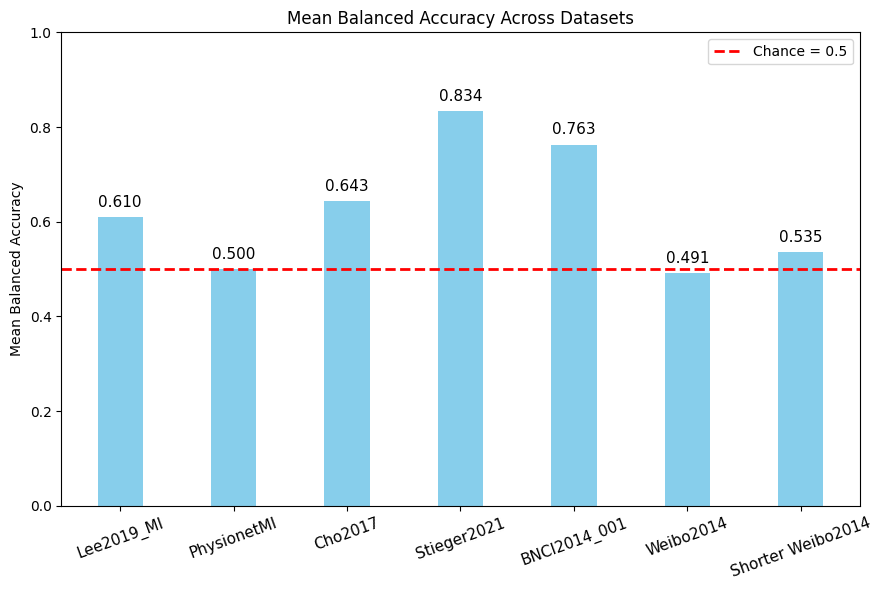

In [79]:
import matplotlib.pyplot as plt

datasets = [
    "Lee2019_MI",
    "PhysionetMI",
    "Cho2017",
    "Stieger2021",
    "BNCI2014_001",
    "Weibo2014",
    "Shorter Weibo2014",
]

balanced_accuracy = [0.610, 0.500, 0.643, 0.834, 0.763, 0.491, 0.535]
chance_level = 0.5

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(datasets, balanced_accuracy, color="skyblue", width=0.4)

ax.axhline(chance_level, color="red", linestyle="--", linewidth=2, label="Chance = 0.5")
ax.set_ylabel("Mean Balanced Accuracy")
ax.set_title("Mean Balanced Accuracy Across Datasets")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=20, labelsize=11)

for bar, value in zip(bars, balanced_accuracy):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
    )

ax.legend()
fig.tight_layout()
plt.show()

## Global Spatial Importance Topomap Comparison

This section loads per-dataset global channel-importance CSVs and compares topomaps in one figure with a shared, interpretable color scale.

In [ ]:
# ---------------------------------------------------------------------
# Global spatial-importance topomap comparison config
# ---------------------------------------------------------------------

from pathlib import Path


NOTEBOOK_DIR = Path.cwd().parent.parent

SPATIAL_IMPORTANCE_CSVS = {
    "Lee2019_MI": "artifacts/moabb-mi-sjepa/Lee2019_MI/20260506_1649_a59a34e0/spatial_conv_analysis/Lee_spatial_channel_importance_global.csv",
    "Cho2017": "artifacts/moabb-mi-sjepa/Cho2017/20260506_1653_b3a6d6ed/spatial_conv_analysis/Cho_spatial_channel_importance_global.csv",
    "Stieger2021": "artifacts/moabb-mi-sjepa/Stieger2021/20260507_1048_54b29b79/spatial_conv_analysis/stieger_spatial_channel_importance_global.csv",
    "PhysionetMI": "artifacts/moabb-mi-sjepa/PhysionetMI/20260506_1700_aa2d5ee5/spatial_conv_analysis/physionet_spatial_channel_importance_global.csv",
    "BNCI2014_001": "artifacts/moabb-mi-sjepa/BNCI2014_001/20260506_1701_34f0bd48/spatial_conv_analysis/BNCI2014_001_spatial_channel_importance_global.csv",
    "Weibo2014_4.2s": "artifacts/moabb-mi-sjepa/Weibo2014/20260507_1114_ab1adb8b/spatial_conv_analysis/weibo4_spatial_channel_importance_global.csv",
    "Weibo2014_8.2s": "artifacts/moabb-mi-sjepa/Weibo2014/20260506_1707_5caee101/spatial_conv_analysis/Weibo8_spatial_channel_importance_global.csv",
}

SPATIAL_TOPO_OUTPUT_DIR = NOTEBOOK_DIR / "spatial_topomap_comparison"

SPATIAL_TOPO_VALUE_COL = "mean_abs_weight"

# Options:
# "raw_shared" = use raw mean_abs_weight with one shared color scale across datasets
# "relative_zscore" = z-score within each dataset, best for visual comparison
# "relative_percent" = percent deviation from dataset mean
SPATIAL_TOPO_MODE = "relative_zscore"

SPATIAL_TOPO_MONTAGE_NAME = "standard_1005"

SPATIAL_TOPO_SHOW_CHANNEL_NAMES = True
SPATIAL_TOPO_DPI = 300

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import mne


def load_spatial_importance_csvs(csv_map, base_dir=None, value_col="mean_abs_weight"):
    if not csv_map:
        raise ValueError("csv_map is empty. Provide at least one dataset path.")

    root = Path(base_dir) if base_dir is not None else NOTEBOOK_DIR
    root = root.expanduser().resolve()

    loaded = {}
    print(f"Loading spatial-importance CSVs relative to: {root}")

    for dataset_name, rel_path in csv_map.items():
        path = Path(rel_path).expanduser()
        if not path.is_absolute():
            path = (root / path).resolve()

        if not path.exists():
            raise FileNotFoundError(
                f"[{dataset_name}] CSV not found: {path}. "
                "Update SPATIAL_IMPORTANCE_CSVS to a valid relative path."
            )

        df = pd.read_csv(path)

        if "channel_name" not in df.columns:
            raise ValueError(f"[{dataset_name}] Missing required column: channel_name")
        if value_col not in df.columns:
            raise ValueError(f"[{dataset_name}] Missing required column: {value_col}")

        loaded[dataset_name] = df
        print(
            f"  Loaded {dataset_name}: {len(df)} channels "
            f"from {path.relative_to(root) if str(path).startswith(str(root)) else path}"
        )

    return loaded


def build_info_from_channel_names(channel_names, sfreq=128.0, montage_name="standard_1005"):
    montage = mne.channels.make_standard_montage(montage_name)
    montage_positions = montage.get_positions()["ch_pos"]

    valid_mask = []
    valid_names = []
    missing_names = []

    for ch in channel_names:
        ch_str = str(ch)
        has_pos = ch_str in montage_positions and np.all(np.isfinite(montage_positions[ch_str]))
        valid_mask.append(has_pos)
        if has_pos:
            valid_names.append(ch_str)
        else:
            missing_names.append(ch_str)

    if not valid_names:
        raise ValueError(
            "No valid montage positions found for channels in this dataset. "
            f"Montage used: {montage_name}"
        )

    info = mne.create_info(ch_names=valid_names, sfreq=float(sfreq), ch_types="eeg")
    info.set_montage(montage, on_missing="ignore")

    if missing_names:
        preview = ", ".join(missing_names[:8])
        suffix = " ..." if len(missing_names) > 8 else ""
        print(
            f"  Warning: {len(missing_names)} channel(s) missing montage positions "
            f"and excluded: {preview}{suffix}"
        )

    return info, np.asarray(valid_mask, dtype=bool)


def transform_spatial_values(values, mode):
    values = np.asarray(values, dtype=float)

    if mode == "raw_shared":
        return values

    if mode == "relative_zscore":
        mean = np.mean(values)
        std = np.std(values)
        if std < 1e-12:
            return np.zeros_like(values)
        return (values - mean) / std

    if mode == "relative_percent":
        mean = np.mean(values)
        if abs(mean) < 1e-12:
            return np.zeros_like(values)
        return 100.0 * (values - mean) / mean

    raise ValueError(f"Unknown mode: {mode}")


def _plot_topomap_compat(data, info, ax, cmap, norm, names):
    kwargs = {
        "data": data,
        "pos": info,
        "axes": ax,
        "show": False,
        "cmap": cmap,
        "contours": 6,
        "names": names,
        "sensors": True,
    }

    try:
        im, _ = mne.viz.plot_topomap(cnorm=norm, **kwargs)
        if names is not None:
            for txt in ax.texts:
                txt.set_fontsize(10)
        return im
    except TypeError:
        pass

    try:
        im, _ = mne.viz.plot_topomap(vlim=(norm.vmin, norm.vmax), **kwargs)
        if names is not None:
            for txt in ax.texts:
                txt.set_fontsize(10)
        return im
    except TypeError:
        pass

    im, _ = mne.viz.plot_topomap(vmin=norm.vmin, vmax=norm.vmax, **kwargs)
    if names is not None:
        for txt in ax.texts:
            txt.set_fontsize(10)
    return im


def plot_spatial_importance_comparison(
    spatial_dfs,
    value_col="mean_abs_weight",
    mode="relative_zscore",
    montage_name="standard_1005",
    show_channel_names=True,
    output_dir=None,
    dpi=300,
):
    if not spatial_dfs:
        raise ValueError("spatial_dfs is empty. Load at least one dataset CSV first.")

    prepared = {}
    all_transformed_values = []

    for dataset_name, df in spatial_dfs.items():
        channel_names = df["channel_name"].astype(str).tolist()
        raw_values = df[value_col].to_numpy(dtype=float)

        info, valid_mask = build_info_from_channel_names(
            channel_names=channel_names,
            sfreq=128.0,
            montage_name=montage_name,
        )

        valid_values = raw_values[valid_mask]
        valid_names = [ch for ch, keep in zip(channel_names, valid_mask) if keep]

        transformed = transform_spatial_values(valid_values, mode=mode)
        prepared[dataset_name] = {
            "info": info,
            "values": transformed,
            "channel_names": valid_names,
        }
        all_transformed_values.append(transformed)

    global_values = np.concatenate(all_transformed_values)

    if mode == "raw_shared":
        vmin, vmax = np.percentile(global_values, [5, 95])
        if not np.isfinite(vmin) or not np.isfinite(vmax) or np.isclose(vmin, vmax):
            delta = max(1e-6, float(np.nanstd(global_values)))
            center = float(np.nanmean(global_values))
            vmin, vmax = center - delta, center + delta
        norm = mcolors.Normalize(vmin=float(vmin), vmax=float(vmax))
        cmap = "viridis"
        cbar_label = value_col
    elif mode == "relative_zscore":
        p2, p98 = np.percentile(global_values, [2, 98])
        lim = max(abs(float(p2)), abs(float(p98)))
        if not np.isfinite(lim) or lim < 1e-6:
            lim = max(1.0, float(np.nanmax(np.abs(global_values))))
        norm = mcolors.TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)
        cmap = "RdBu_r"
        cbar_label = f"within-dataset z-score of {value_col}"
    elif mode == "relative_percent":
        p2, p98 = np.percentile(global_values, [2, 98])
        lim = max(abs(float(p2)), abs(float(p98)))
        if not np.isfinite(lim) or lim < 1e-6:
            lim = max(1.0, float(np.nanmax(np.abs(global_values))))
        norm = mcolors.TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)
        cmap = "RdBu_r"
        cbar_label = f"% deviation from dataset mean {value_col}"
    else:
        raise ValueError(f"Unsupported mode: {mode}")

    n_datasets = len(prepared)
    n_cols = 3 if n_datasets > 3 else n_datasets
    n_rows = int(np.ceil(n_datasets / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.4 * n_cols + 1.0, 3.8 * n_rows),
        squeeze=False,
    )
    flat_axes = axes.ravel()

    for idx, (dataset_name, item) in enumerate(prepared.items()):
        ax = flat_axes[idx]
        names = item["channel_names"] if show_channel_names else None

        _plot_topomap_compat(
            data=item["values"],
            info=item["info"],
            ax=ax,
            cmap=cmap,
            norm=norm,
            names=names,
        )
        ax.set_title(f"{dataset_name} (n={len(item['values'])})", fontsize=13)

    for idx in range(n_datasets, len(flat_axes)):
        flat_axes[idx].axis("off")

    fig.suptitle("Global spatial_conv channel importance comparison", fontsize=14, y=0.995)

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=flat_axes[:n_datasets], fraction=0.025, pad=0.08)
    cbar.set_label(cbar_label)
    cbar.ax.tick_params(labelsize=11)
    cbar.set_label(cbar_label, fontsize=12)

    fig.tight_layout(rect=[0.0, 0.0, 0.86, 0.96])
    fig.subplots_adjust(wspace=0.04, hspace=0.18)

    if output_dir is None:
        output_dir = NOTEBOOK_DIR / "spatial_topomap_comparison"
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    png_path = output_dir / f"global_spatial_importance_comparison_{mode}.png"
    pdf_path = output_dir / f"global_spatial_importance_comparison_{mode}.pdf"

    fig.savefig(png_path, dpi=dpi, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    print(f"Saved figure PNG: {png_path}")
    print(f"Saved figure PDF: {pdf_path}")

    return fig

Loading spatial-importance CSVs relative to: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA
  Loaded Lee2019_MI: 62 channels from artifacts/moabb-mi-sjepa/Lee2019_MI/20260506_1649_a59a34e0/spatial_conv_analysis/Lee_spatial_channel_importance_global.csv
  Loaded Cho2017: 64 channels from artifacts/moabb-mi-sjepa/Cho2017/20260506_1653_b3a6d6ed/spatial_conv_analysis/Cho_spatial_channel_importance_global.csv
  Loaded Stieger2021: 60 channels from artifacts/moabb-mi-sjepa/Stieger2021/20260507_1048_54b29b79/spatial_conv_analysis/stieger_spatial_channel_importance_global.csv
  Loaded PhysionetMI: 64 channels from artifacts/moabb-mi-sjepa/PhysionetMI/20260506_1700_aa2d5ee5/spatial_conv_analysis/physionet_spatial_channel_importance_global.csv
  Loaded BNCI2014_001: 22 channels from artifacts/moabb-mi-sjepa/BNCI2014_001/20260506_1701_34f0bd48/spatial_conv_analysis/BNCI2014_001_spatial_channel_importance_global.csv
  Loaded Weibo2014_4.2s: 60 channels from artifa

/var/folders/7d/njk_0cn503z09dk98r0csptr0000gn/T/ipykernel_18519/857756682.py:245: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.0, 0.0, 0.86, 0.96])


Saved figure PNG: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/spatial_topomap_comparison/global_spatial_importance_comparison_relative_zscore.png
Saved figure PDF: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/spatial_topomap_comparison/global_spatial_importance_comparison_relative_zscore.pdf


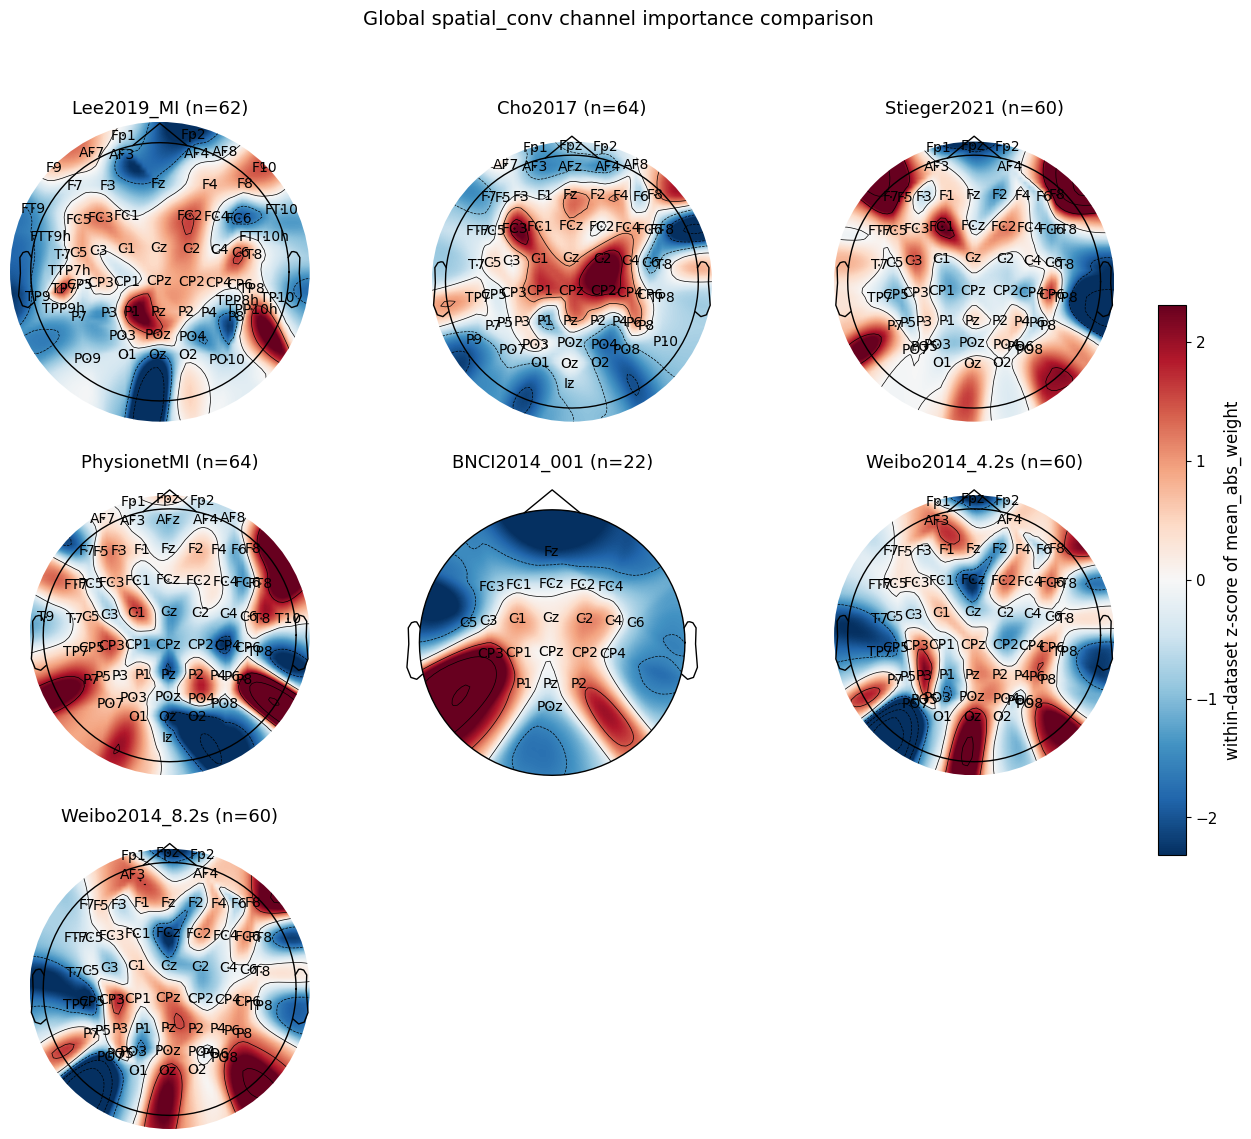

In [82]:
spatial_dfs = load_spatial_importance_csvs(
    SPATIAL_IMPORTANCE_CSVS,
    base_dir=NOTEBOOK_DIR,
    value_col=SPATIAL_TOPO_VALUE_COL,
)

fig = plot_spatial_importance_comparison(
    spatial_dfs=spatial_dfs,
    value_col=SPATIAL_TOPO_VALUE_COL,
    mode=SPATIAL_TOPO_MODE,
    montage_name=SPATIAL_TOPO_MONTAGE_NAME,
    show_channel_names=SPATIAL_TOPO_SHOW_CHANNEL_NAMES,
    output_dir=SPATIAL_TOPO_OUTPUT_DIR,
    dpi=SPATIAL_TOPO_DPI,
)
plt.show()